# Checking what distribution Covasim is using for individual viral load

Initializing sim with 5000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.12 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.13 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.14 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.15 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.15 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.16 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.16 s)  •••••••••••••••••••• 100%

Simulation summary:
           22 cumulative infections
            0 cumulative reinfections
           22 cumulative infectious
           17 cumulative symptomatic cases
            0 cumulative severe cases
            0 cumulative critical cases
           22 cumulative recoveries
            0 cumulative deaths
            0 cumulative tests
            0 cumulative diagnoses
            0 cumulative known deaths
            0 cumulative quarantined people
            0 cumulative isolated peop

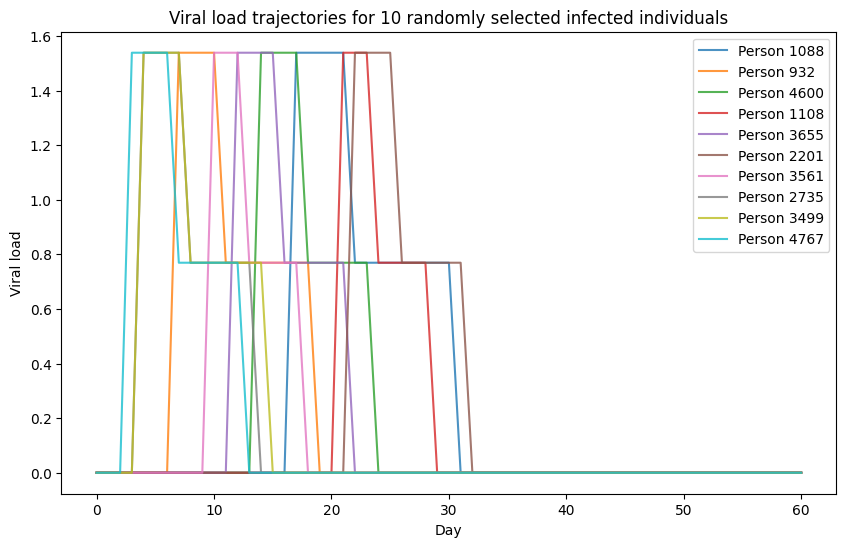

In [2]:
import covasim as cv
import numpy as np
import matplotlib.pyplot as plt

# Simple Simulation
sim = cv.Sim(pop_size=5000, pop_infected=10, n_days=60)
sim.run()

ppl = sim.people

# Extract infected
infected = np.where(~np.isnan(ppl.date_exposed))[0]

# Select 10 people randomly
sample = np.random.choice(infected, size=10, replace=False)

# Viral load
vl = ppl.viral_load  # shape = (pop_size, n_days+1)

# Plot
plt.figure(figsize=(10,6))
for pid in sample:
    plt.plot(vl[pid], alpha=0.8, label=f'Person {pid}')

plt.xlabel('Day')
plt.ylabel('Viral load')
plt.title('Viral load trajectories for 10 randomly selected infected individuals')
plt.legend()
plt.show()


Initializing sim with 5000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.19 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.20 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.22 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.23 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.24 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.25 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.26 s)  •••••••••••••••••••• 100%

Simulation summary:
           22 cumulative infections
            0 cumulative reinfections
           22 cumulative infectious
           17 cumulative symptomatic cases
            0 cumulative severe cases
            0 cumulative critical cases
           22 cumulative recoveries
            0 cumulative deaths
            0 cumulative tests
            0 cumulative diagnoses
            0 cumulative known deaths
            0 cumulative quarantined people
            0 cumulative isolated peop

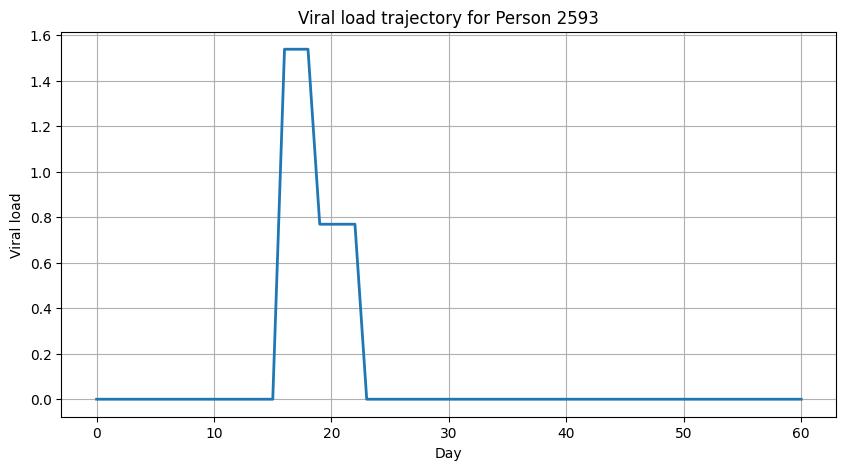

In [3]:
import covasim as cv
import numpy as np
import matplotlib.pyplot as plt

# Simple Simulation
sim = cv.Sim(pop_size=5000, pop_infected=10, n_days=60)
sim.run()

ppl = sim.people

# Extract infected
infected = np.where(~np.isnan(ppl.date_exposed))[0]

# Pick ONE person randomly
pid = np.random.choice(infected)

# Viral load
vl = ppl.viral_load  # shape = (pop_size, n_days+1)

# Plot
plt.figure(figsize=(10,5))
plt.plot(vl[pid], linewidth=2)
plt.xlabel('Day')
plt.ylabel('Viral load')
plt.title(f'Viral load trajectory for Person {pid}')
plt.grid(True)
plt.show()


# Viral Load Reference
viral_dist = The time varying viral load (transmissibility); estimated from Lescure 2020, Lancet, https://doi.org/10.1016/S1473-3099(20)30200-0

Clinical and virological data of the first cases of COVID-19 in Europe: a case series (Lescure 2020, Lancet, https://doi.org/10.1016/S1473-3099(20)30200-0)

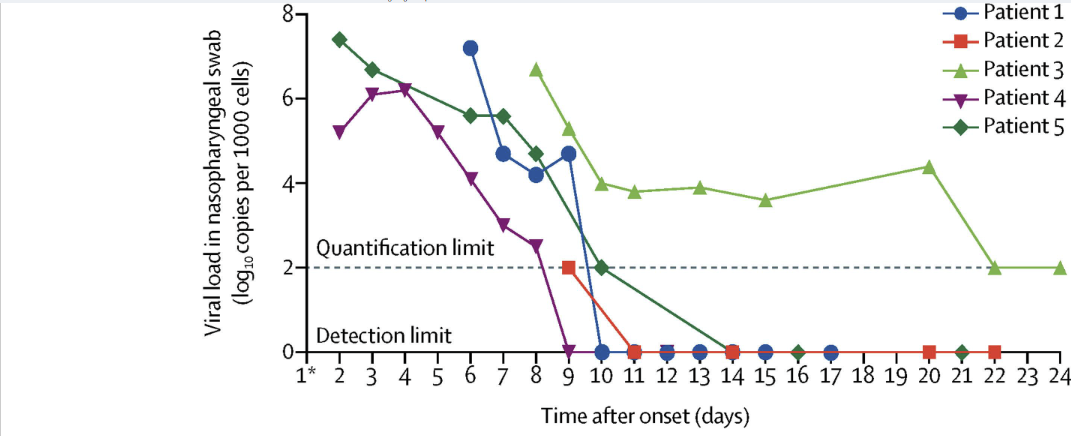


# Proposed Ideas for Model Validation and Sampling Strategy

## 1. Validation and calibration of the sequence‑evolution module
Validate the sequence‑evolution component of the model using real data from a specific region in San Diego, where both clinical case data and wastewater sequencing data are available for the same time period.

The workflow would be:

Step 1: Calibrate a Covasim simulation to the clinical data so that the epidemic trajectory matches observed cases.

Step 2: Using the calibrated parameters, run the simulation with the sequence‑evolution module enabled.

Step 3: Compare the model‑generated mutation counts and mutation patterns with the mutations observed in wastewater sequencing for the same region and time window.

Assess how well the model’s mutation‑generation assumptions reflect real‑world evolutionary dynamics.

## 2. Pipeline for estimating minimum sequencing sampling frequency
Develop a pipeline that determines the minimum sequencing frequency required to reliably detect emerging mutations or outbreaks in each region.

The pipeline would use:

- historical clinical data

- wastewater sequencing data

to estimate how often sequencing should be performed to capture relevant evolutionary or epidemiological signals.

Open questions include:

How do we define “important” mutations?
(Do we aim to detect every novel mutation, or only those with potential functional or epidemiological relevance?)

Do all regions need the same sampling frequency, or should it adapt to local transmission dynamics?

The pipeline could take each region’s existing data as input and output a recommended minimum sampling interval. As new data accumulate, the recommended sampling frequency would update dynamically.



# Ascertainment Reference Paper

Ascertainment rate of SARS-CoV-2 infections from healthcare and community testing in the UK
J Theor Biol. 2022 Nov 5;558:111333. doi: 10.1016/j.jtbi.2022.111333

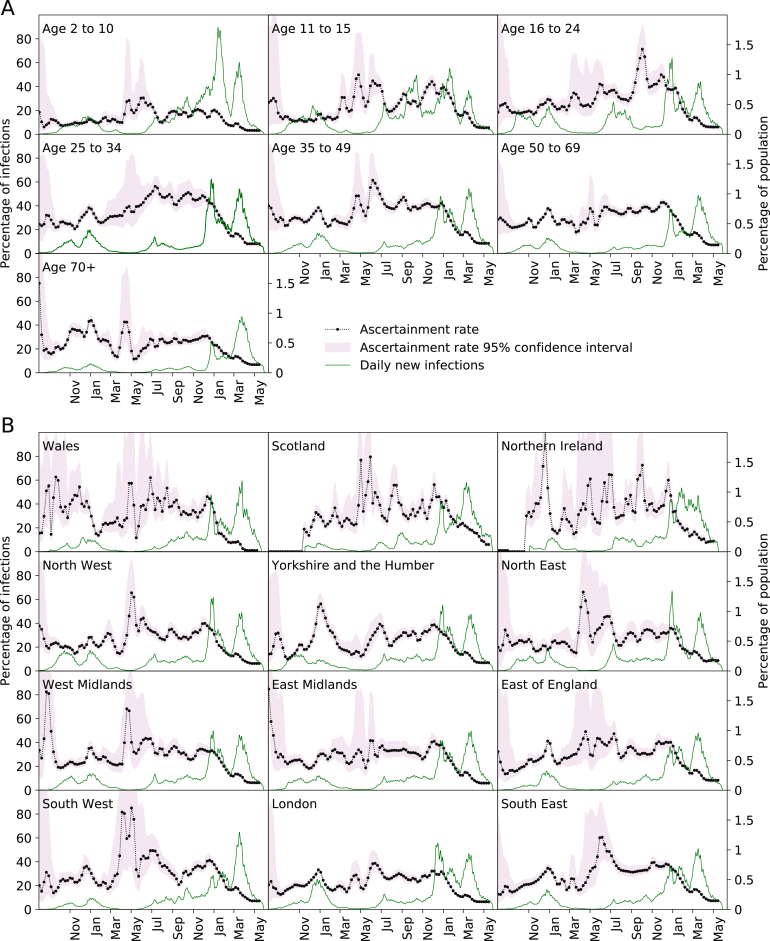